In [1]:
import cv2
import os
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
from keras.layers import Dropout, Dense, Flatten, Conv2D, MaxPool2D, Input

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Cats_Dogs.zip to Cats_Dogs.zip


In [3]:
import zipfile
with zipfile.ZipFile('Cats_Dogs.zip', 'r') as zip_ref:
  zip_ref.extractall('data/') 

In [4]:
cat_folder = 'data/Cat/'
dog_folder = 'data/Dog/'

def get_image_shapes(folder_path):
    shapes = []
    corrupted = []
    for filename in tqdm(os.listdir(folder_path)):
        if filename.lower().endswith(('.jpg', '.png', '.jpeg')):
            img_path = os.path.join(folder_path, filename)
            img = cv2.imread(img_path)
            if img is not None:
                shapes.append(img.shape)
            else:
                corrupted.append(filename)
    return shapes, corrupted

In [5]:
# Get shapes of both folders:
cat_shapes, cat_corrupted = get_image_shapes(cat_folder)
dog_shapes, dog_corrupted = get_image_shapes(dog_folder)

100%|██████████| 73/73 [00:00<00:00, 1070.97it/s]


# Check the size of all images

In [6]:
from collections import Counter

cat_shape_counts = Counter(cat_shapes)
dog_shape_counts = Counter(dog_shapes)

print("Cat image shape distribution:")
print(cat_shape_counts)

print("\nDog image shape distribution:")
print(dog_shape_counts)

Cat image shape distribution:
Counter({(374, 500, 3): 11, (375, 499, 3): 7, (383, 499, 3): 1, (414, 500, 3): 1, (258, 448, 3): 1, (353, 405, 3): 1, (291, 335, 3): 1, (223, 320, 3): 1, (377, 500, 3): 1, (499, 500, 3): 1, (262, 349, 3): 1, (256, 334, 3): 1, (499, 375, 3): 1, (303, 400, 3): 1, (425, 320, 3): 1, (196, 299, 3): 1, (214, 258, 3): 1, (500, 344, 3): 1, (176, 180, 3): 1, (144, 175, 3): 1, (410, 431, 3): 1, (331, 464, 3): 1, (345, 461, 3): 1, (499, 431, 3): 1, (300, 399, 3): 1, (382, 499, 3): 1, (280, 300, 3): 1, (396, 312, 3): 1, (500, 356, 3): 1, (479, 370, 3): 1, (473, 256, 3): 1, (370, 500, 3): 1, (337, 350, 3): 1, (499, 333, 3): 1, (267, 320, 3): 1, (224, 300, 3): 1, (93, 139, 3): 1, (337, 499, 3): 1, (181, 249, 3): 1, (129, 180, 3): 1, (332, 499, 3): 1, (500, 374, 3): 1, (102, 107, 3): 1, (499, 489, 3): 1, (457, 492, 3): 1, (500, 345, 3): 1, (433, 400, 3): 1, (311, 500, 3): 1, (315, 499, 3): 1, (173, 237, 3): 1, (270, 286, 3): 1, (226, 328, 3): 1, (499, 495, 3): 1, (426, 4

# Resizing images

In [7]:
# Create new folders to save resized images
resized_cat_folder = 'resized/Cat/'
resized_dog_folder = 'resized/Dog/'
os.makedirs(resized_cat_folder, exist_ok = True)
os.makedirs(resized_dog_folder, exist_ok = True)

# Function to resize and save images
def resize_images(input_folder, output_folder, target_size = (128, 128)):
    for filename in tqdm(os.listdir(input_folder)):
        if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
            img_path = os.path.join(input_folder, filename)
            img = cv2.imread(img_path)
            if img is not None:
                resized_img = cv2.resize(img, target_size)
                save_path = os.path.join(output_folder, filename)
                cv2.imwrite(save_path, resized_img)

# Resize both cat and dog images
resize_images(cat_folder, resized_cat_folder)
resize_images(dog_folder, resized_dog_folder)

100%|██████████| 73/73 [00:00<00:00, 529.58it/s]


In [8]:
resized_cat_shapes, _, = get_image_shapes(resized_cat_folder)
resized_dog_shapes, _, = get_image_shapes(resized_dog_folder)

from collections import Counter

print("Resized Cat image shape distribution:")
print(Counter(resized_cat_shapes))

print("\nResized Dog image shape distribution:")
print(Counter(resized_dog_shapes))


100%|██████████| 73/73 [00:00<00:00, 3362.85it/s]

Resized Cat image shape distribution:
Counter({(128, 128, 3): 71})

Resized Dog image shape distribution:
Counter({(128, 128, 3): 73})


In [9]:
!pip install split-folders

import splitfolders

splitfolders.ratio("resized", output = "data_split", seed = 42, ratio = (.7, .15, .15)) 

Copying files: 144 files [00:00, 6595.83 files/s]


In [10]:
import tensorflow as tf

img_size = (128, 128)

train_ds = tf.keras.utils.image_dataset_from_directory(
    "data_split/train",
    image_size = img_size,
    batch_size = 32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "data_split/val",
    image_size = img_size,
    batch_size = 32
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    "data_split/test",
    image_size = img_size,
    batch_size = 32
)


Found 100 files belonging to 2 classes.
Found 20 files belonging to 2 classes.
Found 24 files belonging to 2 classes.


In [11]:
from tensorflow.keras.applications import EfficientNetV2B0
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input
AUTOTUNE = tf.data.AUTOTUNE

# Apply preprocessing:
train_ds = train_ds.map(lambda x, y: (preprocess_input(x), y), num_parallel_calls = AUTOTUNE)
val_ds = val_ds.map(lambda x, y: (preprocess_input(x), y), num_parallel_calls = AUTOTUNE)
test_ds = test_ds.map(lambda x, y: (preprocess_input(x), y), num_parallel_calls = AUTOTUNE)

pre_model = EfficientNetV2B0(weights = 'imagenet', include_top = False, input_shape = (128, 128, 3))


24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [12]:
train_ds = train_ds.prefetch(buffer_size = AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size = AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size = AUTOTUNE)


In [13]:
pre_model.summary()

Model: "efficientnetv2-b0"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 128, 128,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 128, 128,  │          0 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 64, 64,    │        864 │ normalization[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 64, 64,    │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 64, 64,    │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 64, 64,    │      4,608 │ stem_activation[… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_bn  │ (None, 64, 64,    │         64 │ block1a_project_… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_ac… │ (None, 64, 64,    │          0 │ block1a_project_… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_conv │ (None, 32, 32,    │      9,216 │ block1a_project_… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_bn   │ (None, 32, 32,    │        256 │ block2a_expand_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_act… │ (None, 32, 32,    │          0 │ block2a_expand_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_project_co… │ (None, 32, 32,    │      2,048 │ block2a_expand_a… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_project_bn  │ (None, 32, 32,    │        128 │ block2a_project_… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_conv │ (None, 32, 32,    │     36,864 │ block2a_project_… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_bn   │ (None, 32, 32,    │        512 │ block2b_expand_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_act… │ (None, 32, 32,    │          0 │ block2b_expand_b

 Total params: 5,919,312 (22.58 MB)

 Trainable params: 5,858,704 (22.35 MB)

 Non-trainable params: 60,608 (236.75 KB)

In [14]:
for layer in pre_model.layers:
    layer.trainable = False # Freeze all the layers


In [15]:
pre_model.summary()

Model: "efficientnetv2-b0"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 128, 128,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 128, 128,  │          0 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 64, 64,    │        864 │ normalization[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 64, 64,    │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 64, 64,    │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 64, 64,    │      4,608 │ stem_activation[… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_bn  │ (None, 64, 64,    │         64 │ block1a_project_… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_ac… │ (None, 64, 64,    │          0 │ block1a_project_… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_conv │ (None, 32, 32,    │      9,216 │ block1a_project_… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_bn   │ (None, 32, 32,    │        256 │ block2a_expand_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_act… │ (None, 32, 32,    │          0 │ block2a_expand_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_project_co… │ (None, 32, 32,    │      2,048 │ block2a_expand_a… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_project_bn  │ (None, 32, 32,    │        128 │ block2a_project_… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_conv │ (None, 32, 32,    │     36,864 │ block2a_project_… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_bn   │ (None, 32, 32,    │        512 │ block2b_expand_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_act… │ (None, 32, 32,    │          0 │ block2b_expand_b

 Total params: 5,919,312 (22.58 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 5,919,312 (22.58 MB)

In [16]:
reg = keras.regularizers.l2(0.01)
model = keras.models.Sequential()
model.add(pre_model)
model.add(Flatten())
model.add(Dropout(0.6))
model.add(Dense(2, activation = 'softmax', kernel_regularizer = reg))

In [17]:
opt = tf.optimizers.Adam(learning_rate = 0.001)
loss = tf.losses.SparseCategoricalCrossentropy()
metric = tf.metrics.SparseCategoricalAccuracy()
model.compile(optimizer = opt, loss = loss, metrics = [metric])

In [18]:
callbacks = [keras.callbacks.ModelCheckpoint(filepath = 'model_pretrain.keras', monitor = 'val_loss')]
history = model.fit(train_ds, validation_data = val_ds, epochs = 20, batch_size = 32, validation_split = 0.15, verbose = 2, callbacks = callbacks)


Epoch 1/20
4/4 - 24s - 6s/step - loss: 0.9899 - sparse_categorical_accuracy: 0.6000 - val_loss: 0.3098 - val_sparse_categorical_accuracy: 0.9000
Epoch 2/20
4/4 - 5s - 1s/step - loss: 0.1966 - sparse_categorical_accuracy: 0.9200 - val_loss: 0.2192 - val_sparse_categorical_accuracy: 0.9500
Epoch 3/20
4/4 - 5s - 1s/step - loss: 0.0850 - sparse_categorical_accuracy: 0.9800 - val_loss: 0.2214 - val_sparse_categorical_accuracy: 0.9500
Epoch 4/20
4/4 - 4s - 1s/step - loss: 0.0599 - sparse_categorical_accuracy: 1.0000 - val_loss: 0.2389 - val_sparse_categorical_accuracy: 0.9500
Epoch 5/20
4/4 - 5s - 1s/step - loss: 0.0511 - sparse_categorical_accuracy: 1.0000 - val_loss: 0.2508 - val_sparse_categorical_accuracy: 0.9500
Epoch 6/20
4/4 - 4s - 920ms/step - loss: 0.0527 - sparse_categorical_accuracy: 1.0000 - val_loss: 0.2562 - val_sparse_categorical_accuracy: 0.9500
Epoch 7/20
4/4 - 4s - 1s/step - loss: 0.0516 - sparse_categorical_accuracy: 1.0000 - val_loss: 0.2585 - val_sparse_categorical_accur

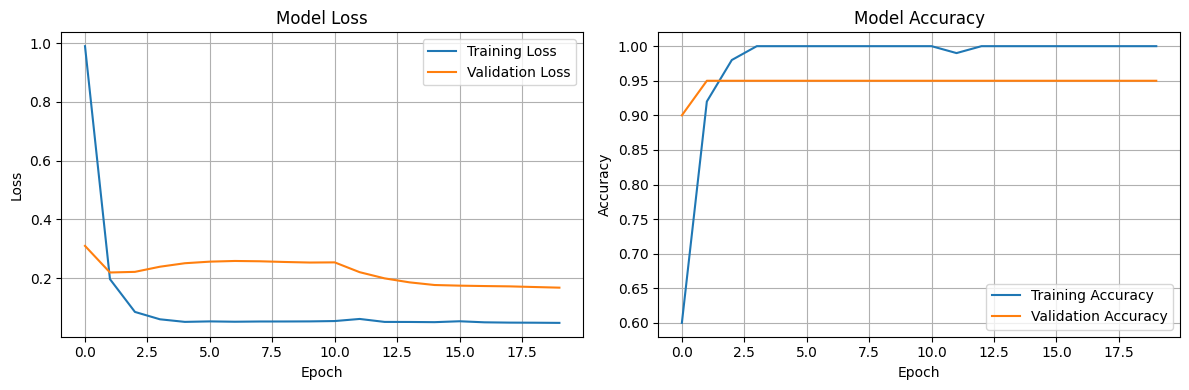

In [19]:
plt.figure(figsize = (12, 4))

# Loss:
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label = 'Training Loss')
plt.plot(history.history['val_loss'], label = 'Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Accuracy:
plt.subplot(1, 2, 2)
plt.plot(history.history['sparse_categorical_accuracy'], label = 'Training Accuracy')
plt.plot(history.history['val_sparse_categorical_accuracy'], label = 'Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [20]:
best_model = keras.saving.load_model('model_pretrain.keras')
model.evaluate(test_ds)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 392ms/step - loss: 0.0503 - sparse_categorical_accuracy: 1.0000


[0.050261396914720535, 1.0]